# Analise exploratoria

Analise feita a partir do arquivo bruto `data/raw/credit_score.csv`.

Objetivos:
- entender a estrutura e a granularidade da base
- valores invalidos e colunas sensiveis
- avaliar o comportamento da variavel resposta `Credit_Score`
- transformar os achados em decisoes objetivas de pre-processamento


## 1. Leitura do problema e das variaveis

As variaveis representam informacoes cadastrais, comportamento de credito, perfil de pagamento e saldo mensal do cliente.

Pontos importantes:
- `ID`, `Name` e `SSN` sao identificadores e nao devem ir para modelagem
- `Customer_ID` identifica o cliente ao longo dos meses
- `Month` indica que a base tem componente temporal
- `Credit_Score` é a target original em tres classes (`Good`, `Standard`, `Poor`)

In [24]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', 200)

RAW_PATH = Path('../data/raw/credit_score.csv')
df = pd.read_csv(RAW_PATH, low_memory=False)

print(f'Caminho: {RAW_PATH.resolve()}')
print(f'Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas')

Caminho: C:\Users\guilh\repos_github\credit-scoring-model\data\raw\credit_score.csv
Shape: 100,000 linhas x 28 colunas


In [25]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 2. Estrutura da base

In [26]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(dropna=True)
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, False])

overview

,dtype,missing,missing_pct,n_unique
Monthly_Inhand_Salary,float64,15002,15.00,13235
Type_of_Loan,str,11408,11.41,6260
Name,str,9985,9.98,10139
Credit_History_Age,str,9030,9.03,404
Num_of_Delayed_Payment,str,7002,7.00,749
Amount_invested_monthly,str,4479,4.48,91049
Num_Credit_Inquiries,float64,1965,1.96,1223
Monthly_Balance,str,1200,1.20,98792
ID,str,0,0.00,100000
Credit_Utilization_Ratio,float64,0,0.00,100000


In [27]:
print('Clientes unicos:', df['Customer_ID'].nunique())
print('Meses observados:', sorted(df['Month'].dropna().unique().tolist()))
print('Duplicados de ID:', df['ID'].duplicated().sum())
print('Duplicados por Customer_ID + Month:', df.duplicated(['Customer_ID', 'Month']).sum())
print('\nRegistros por cliente:')
display(df.groupby('Customer_ID').size().value_counts().sort_index().rename('n_customers').to_frame())

Clientes unicos: 12500
Meses observados: ['April', 'August', 'February', 'January', 'July', 'June', 'March', 'May']
Duplicados de ID: 0
Duplicados por Customer_ID + Month: 0

Registros por cliente:


,n_customers
8,12500


## 3. Variavel alvo

A base original traz `Credit_Score` em tres classes. Para o problema de inadimplencia, faz sentido avaliar uma transformacao binaria onde `Poor = 1` e `Good/Standard = 0`.

,credit_score_count,credit_score_pct
Credit_Score,,
Standard,53174,53.17
Poor,28998,29.00
Good,17828,17.83


C:\Users\guilh\AppData\Local\Temp\ipykernel_21080\740867576.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df, x='Credit_Score', order=order, palette=palette)
C:\Users\guilh\AppData\Local\Temp\ipykernel_21080\740867576.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(x=target_bin_str, palette=palette_bin)


Text(0.5, 1.0, 'Target binária derivada')

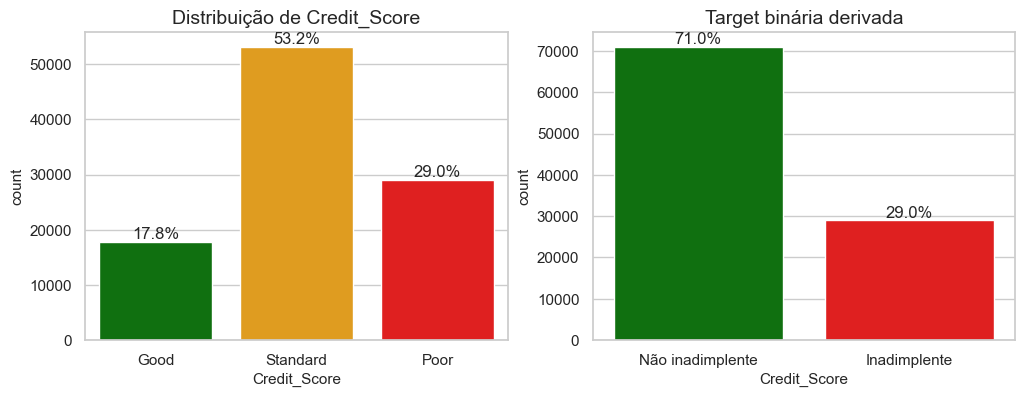

In [30]:
target_multi = df['Credit_Score'].value_counts(dropna=False)
target_bin = (df['Credit_Score'] == 'Poor').astype(int)

display(pd.DataFrame({
    'credit_score_count': target_multi,
    'credit_score_pct': (target_multi / len(df) * 100).round(2)
}))

plt.figure(figsize=(12, 4))

# -------------------------
# Gráfico 1 - Multiclasse
# -------------------------
plt.subplot(1, 2, 1)

order = ['Good', 'Standard', 'Poor']
palette = {
    'Good': 'green',
    'Standard': 'orange',
    'Poor': 'red'
}

ax1 = sns.countplot(data=df, x='Credit_Score', order=order, palette=palette)

total = len(df)

for p in ax1.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax1.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribuição de Credit_Score')


# -------------------------
# Gráfico 2 - Binário
# -------------------------
plt.subplot(1, 2, 2)

target_bin_str = target_bin.astype(str)

palette_bin = {
    '0': 'green',
    '1': 'red'
}

ax2 = sns.countplot(x=target_bin_str, palette=palette_bin)

plt.xticks([0, 1], ['Não inadimplente', 'Inadimplente'])

total = len(df)

for p in ax2.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax2.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Target binária derivada')

## 4. Qualidade dos dados

Nesta etapa separamos ausencia real de valores corrompidos por placeholders.

,feature,missing_pct
0,Monthly_Inhand_Salary,15.002
1,Type_of_Loan,11.408
2,Name,9.985
3,Credit_History_Age,9.030
4,Num_of_Delayed_Payment,7.002
5,Amount_invested_monthly,4.479
6,Num_Credit_Inquiries,1.965
7,Monthly_Balance,1.200


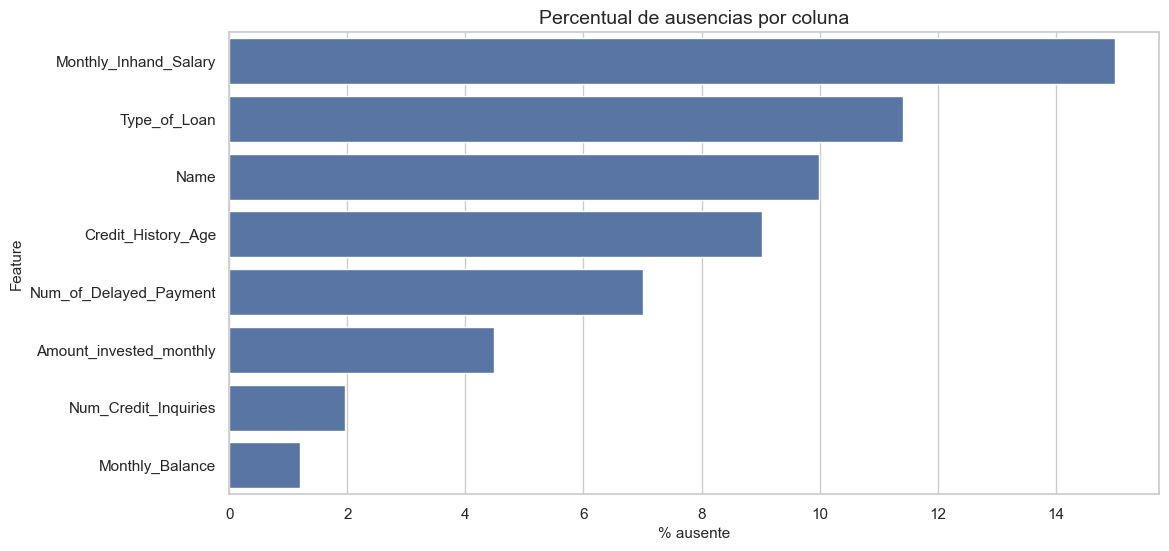

In [31]:
missing_df = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing_df.columns = ['feature', 'missing_pct']

display(missing_df[missing_df['missing_pct'] > 0])

plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df[missing_df['missing_pct'] > 0], x='missing_pct', y='feature')
plt.title('Percentual de ausencias por coluna')
plt.xlabel('% ausente')
plt.ylabel('Feature')
plt.show()

In [32]:
placeholder_tokens = ['_', '_______', 'NM', '!@9#%8', '__10000__', '__-333333333333333333333333333__']
rows = []

for token in placeholder_tokens:
    for col in df.columns:
        count = int((df[col].astype(str) == token).sum())
        if count > 0:
            rows.append({
                'placeholder': token,
                'feature': col,
                'count': count,
                'pct': round(count / len(df) * 100, 2)
            })

pd.DataFrame(rows).sort_values(['pct', 'count'], ascending=False)

,placeholder,feature,count,pct
1,_,Credit_Mix,20195,20.20
3,NM,Payment_of_Min_Amount,12007,12.01
4,!@9#%8,Payment_Behaviour,7600,7.60
2,_______,Occupation,7062,7.06
5,__10000__,Amount_invested_monthly,4305,4.30
0,_,Changed_Credit_Limit,2091,2.09
6,__-333333333333333333333333333__,Monthly_Balance,9,0.01


## 5. Variaveis numericas: conversao e anomalias

Varias colunas numericas vieram como texto por causa de sufixos com `_` e valores corrompidos. Antes de olhar distribuicoes, convertemos tudo para numero.

In [33]:
numeric_candidates = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance'
]

df_num = df.copy()
for col in numeric_candidates:
    cleaned = df_num[col].astype(str).str.replace('_', '', regex=False)
    df_num[col] = pd.to_numeric(cleaned, errors='coerce')

df_num[numeric_candidates].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106500e+02,6.862400e+02,-5.000000e+02,24.00,33.00,42.00,8698.00
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.50,37578.61,72790.92,24198062.00
Monthly_Inhand_Salary,84998.0,4.194170e+03,3.183690e+03,3.036500e+02,1625.57,3093.75,5957.45,15204.63
Num_Bank_Accounts,100000.0,1.709000e+01,1.174000e+02,-1.000000e+00,3.00,6.00,7.00,1798.00
Num_Credit_Card,100000.0,2.247000e+01,1.290600e+02,0.000000e+00,4.00,5.00,7.00,1499.00
Interest_Rate,100000.0,7.247000e+01,4.664200e+02,1.000000e+00,8.00,13.00,20.00,5797.00
Num_of_Loan,100000.0,3.010000e+00,6.265000e+01,-1.000000e+02,1.00,3.00,5.00,1496.00
Delay_from_due_date,100000.0,2.107000e+01,1.486000e+01,-5.000000e+00,10.00,18.00,28.00,67.00
Num_of_Delayed_Payment,92998.0,3.092000e+01,2.260300e+02,-3.000000e+00,9.00,14.00,18.00,4397.00
Changed_Credit_Limit,97909.0,1.039000e+01,6.790000e+00,-6.490000e+00,5.32,9.40,14.87,36.97


In [34]:
rules = {
    'Age': df_num['Age'].between(18, 100),
    'Annual_Income': df_num['Annual_Income'].between(1000, 1_000_000),
    'Num_Bank_Accounts': df_num['Num_Bank_Accounts'].between(0, 20),
    'Num_Credit_Card': df_num['Num_Credit_Card'].between(0, 20),
    'Interest_Rate': df_num['Interest_Rate'].between(0, 100),
    'Num_of_Loan': df_num['Num_of_Loan'].between(0, 20),
    'Delay_from_due_date': df_num['Delay_from_due_date'].between(0, 365),
    'Num_of_Delayed_Payment': df_num['Num_of_Delayed_Payment'].between(0, 100),
    'Num_Credit_Inquiries': df_num['Num_Credit_Inquiries'].between(0, 100),
    'Monthly_Balance': df_num['Monthly_Balance'].between(0, 200_000)
}

invalid_summary = pd.DataFrame({
    'feature': list(rules.keys()),
    'invalid_count': [int((~mask & df_num[col].notna()).sum()) for col, mask in rules.items()],
})
invalid_summary['invalid_pct'] = (invalid_summary['invalid_count'] / len(df_num) * 100).round(2)
invalid_summary.sort_values('invalid_count', ascending=False)

,feature,invalid_count,invalid_pct
0,Age,8482,8.48
5,Num_of_Loan,4345,4.35
3,Num_Credit_Card,2263,2.26
4,Interest_Rate,2012,2.01
8,Num_Credit_Inquiries,1602,1.60
7,Num_of_Delayed_Payment,1368,1.37
2,Num_Bank_Accounts,1335,1.34
1,Annual_Income,961,0.96
6,Delay_from_due_date,591,0.59
9,Monthly_Balance,9,0.01


,corr_target
Delay_from_due_date,0.373089
Outstanding_Debt,0.362518
Monthly_Inhand_Salary,-0.164341
Changed_Credit_Limit,0.062169
Credit_Utilization_Ratio,-0.037347
Num_Credit_Inquiries,0.010061
Annual_Income,-0.009583
Num_Bank_Accounts,0.008890
Num_of_Loan,0.008605
Num_Credit_Card,0.007463


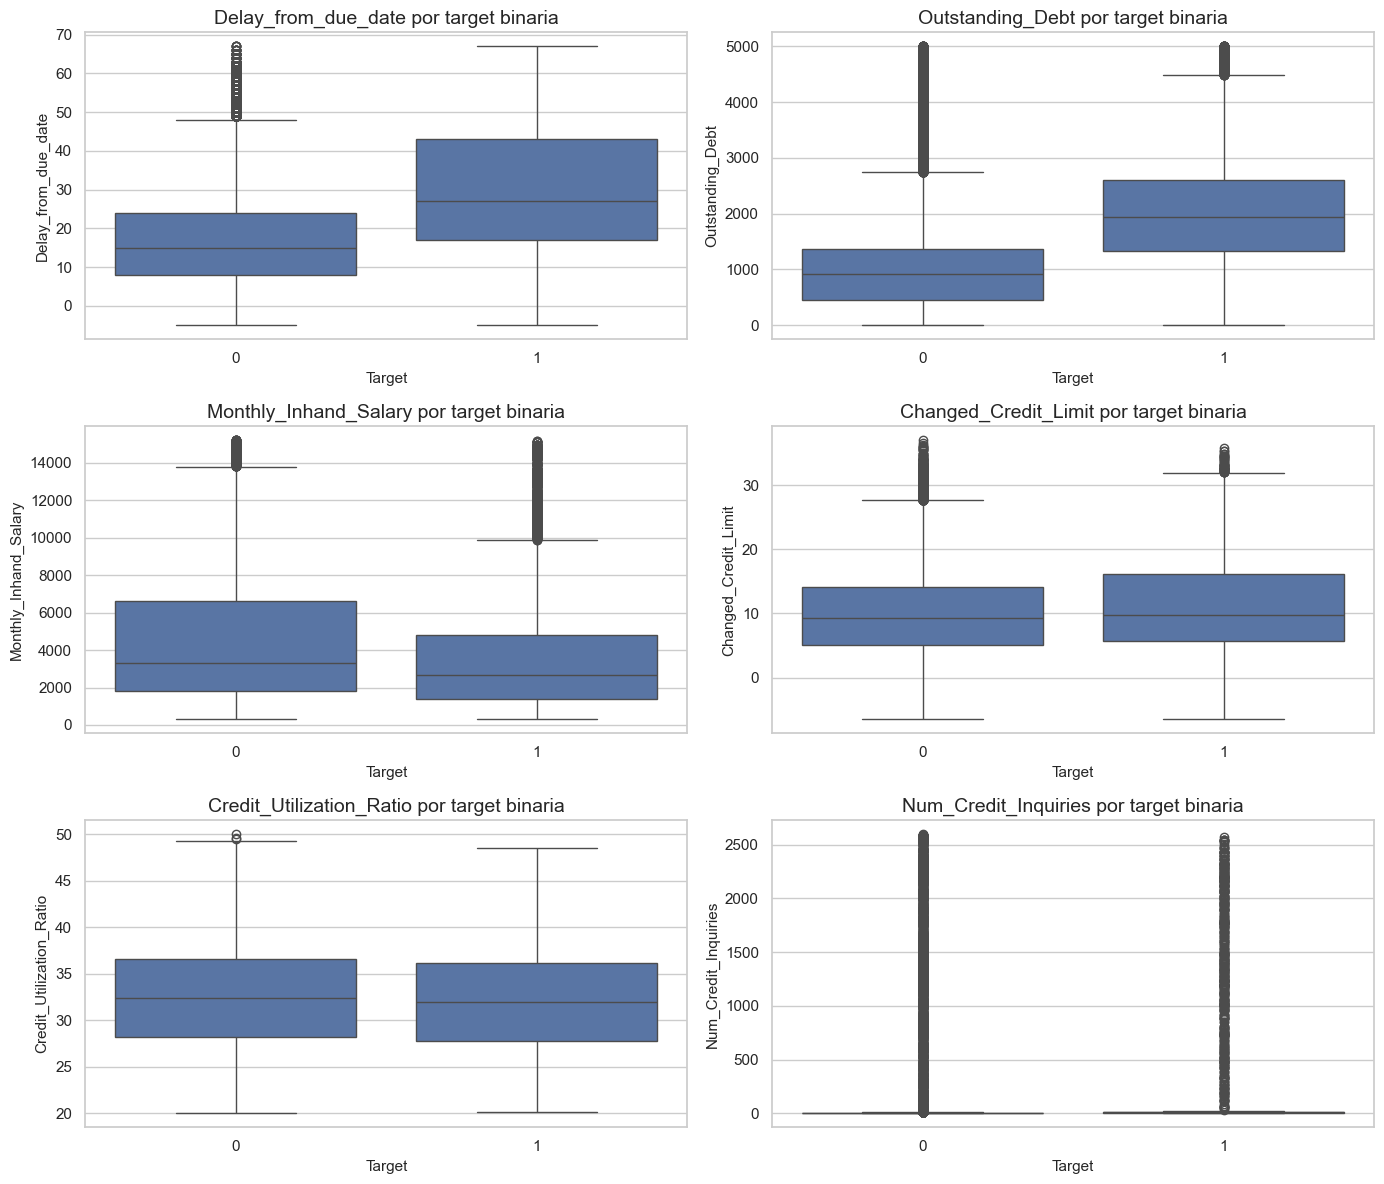

In [35]:
df_num['target'] = (df_num['Credit_Score'] == 'Poor').astype(int)
corr_target = (
    df_num[numeric_candidates + ['target']]
    .corr(numeric_only=True)['target']
    .drop('target')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

top_numeric = corr_target.head(6).index.tolist()
display(corr_target.to_frame('corr_target'))

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
for ax, col in zip(axes, top_numeric):
    sns.boxplot(data=df_num, x='target', y=col, ax=ax)
    ax.set_title(f'{col} por target binaria')
    ax.set_xlabel('Target')
for ax in axes[len(top_numeric):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Variaveis categoricas

Algumas variaveis categoricas parecem estaveis por cliente (`Occupation`), outras sao comportamentais e mudam ao longo dos meses (`Payment_Behaviour`, `Payment_of_Min_Amount`).

In [36]:
categorical_cols = ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']

for col in categorical_cols:
    print(f'\n### {col}')
    display(df[col].value_counts(dropna=False).head(10).to_frame('count'))


### Month


,count
Month,
January,12500
February,12500
March,12500
April,12500
May,12500
June,12500
July,12500
August,12500



### Occupation


,count
Occupation,
_______,7062
Lawyer,6575
Architect,6355
Engineer,6350
Scientist,6299
Mechanic,6291
Accountant,6271
Developer,6235
Media_Manager,6232



### Type_of_Loan


...

,count
Payment_of_Min_Amount,
Yes,52326
No,35667
NM,12007



### Payment_Behaviour


,count
Payment_Behaviour,
Low_spent_Small_value_payments,25513
High_spent_Medium_value_payments,17540
Low_spent_Medium_value_payments,13861
High_spent_Large_value_payments,13721
High_spent_Small_value_payments,11340
Low_spent_Large_value_payments,10425
!@9#%8,7600



### Credit_Score


,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [37]:
df_cat = df.copy()
df_cat['target'] = (df_cat['Credit_Score'] == 'Poor').astype(int)

def category_risk_table(dataframe, column, top_n=10):
    summary = (
        dataframe.groupby(column, dropna=False)
        .agg(qtd=('target', 'size'), inadimplencia=('target', 'mean'))
        .sort_values('qtd', ascending=False)
        .head(top_n)
        .reset_index()
    )
    summary['inadimplencia'] = (summary['inadimplencia'] * 100).round(2)
    return summary

key_categoricals = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

In [38]:
for col in key_categoricals:
    print(f'\n### {col}')
    display(category_risk_table(df_cat, col))


### Occupation


,Occupation,qtd,inadimplencia
0,_______,7062,28.76
1,Lawyer,6575,27.53
2,Architect,6355,27.29
3,Engineer,6350,30.43
4,Scientist,6299,30.50
5,Mechanic,6291,30.14
6,Accountant,6271,29.96
7,Developer,6235,28.74
8,Media_Manager,6232,26.40
9,Teacher,6215,30.49



### Credit_Mix


,Credit_Mix,qtd,inadimplencia
0,Standard,36479,21.54
1,Good,24337,15.86
2,_,20195,29.06
3,Bad,18989,60.08



### Payment_of_Min_Amount


,Payment_of_Min_Amount,qtd,inadimplencia
0,Yes,52326,39.57
1,No,35667,13.38
2,NM,12007,29.30



### Payment_Behaviour


,Payment_Behaviour,qtd,inadimplencia
0,Low_spent_Small_value_payments,25513,35.77
1,High_spent_Medium_value_payments,17540,25.31
2,Low_spent_Medium_value_payments,13861,30.38
3,High_spent_Large_value_payments,13721,21.71
4,High_spent_Small_value_payments,11340,27.23
5,Low_spent_Large_value_payments,10425,28.12
6,!@9#%8,7600,29.28


## 7. Consistencia por cliente

Como temos 8 meses por cliente, vale verificar quais campos parecem ser estruturais e podem ser imputados pelo proprio historico do cliente.

In [39]:
stability_cols = ['Age', 'Annual_Income', 'Occupation', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan']
stability_rows = []

for col in stability_cols:
    series = df[col].astype(str).str.replace('_', '', regex=False)
    nunique_per_customer = series.groupby(df['Customer_ID']).nunique(dropna=True)
    stability_rows.append({
        'feature': col,
        'customers_single_value': int((nunique_per_customer == 1).sum()),
        'customers_multi_value': int((nunique_per_customer > 1).sum())
    })

pd.DataFrame(stability_rows)

,feature,customers_single_value,customers_multi_value
0,Age,4193,8307
1,Annual_Income,11535,965
2,Occupation,6950,5550
3,Num_Bank_Accounts,10973,1527
4,Num_Credit_Card,10119,2381
5,Interest_Rate,10589,1911
6,Num_of_Loan,8757,3743


## 8. Decisoes de pre-processamento

Com base na EDA, as decisoes recomendadas sao:

1. Remover identificadores sem valor preditivo direto: `ID`, `Name`, `SSN`.
2. Manter `Customer_ID` e `Month` nesta etapa porque eles ajudam no tratamento temporal e na engenharia de features.
3. Substituir placeholders por `NaN`:
   - `Occupation = _______`
   - `Credit_Mix = _`
   - `Payment_of_Min_Amount = NM`
   - `Payment_Behaviour = !@9#%8`
   - `Amount_invested_monthly = __10000__`
   - `Monthly_Balance = __-333333333333333333333333333__`
4. Corrigir colunas numericas com sufixos `_` e converter para tipo numerico.
5. Tratar valores fora de faixa como ausentes antes da imputacao.
6. Imputar variaveis estruturais por mediana ou moda do proprio cliente.
7. Converter `Credit_History_Age` para meses e preencher a sequencia por cliente.
8. Criar `target` binaria usando `Poor = 1` e `Good/Standard = 0`.
9. Salvar a base tratada em `data/processed/credit_score_clean.csv`.


## 9. Conclusao

A base tem um bom volume e uma estrutura temporal clara, mas chega com bastante sujeira de entrada: placeholders, colunas numericas como texto, valores extremos impossiveis e identificadores sensiveis.

Isso justifica um pre-processamento mais forte antes de qualquer modelagem.